# 08 — OpenAI Agents SDK: one shop, three wirings

Modules 02–07 built the loop by hand, then showed `await`. The SDK first look in 02 was one agent, one tool, and a trace.

Today the product is **more than one agent**, and the question is **who decides the next step**. That is module 01 again, inside a framework.

The shop is Chinook — the music store from the opening riddle. Named tools. No free-form SQL. The model still does not touch the database.

Three orchestration options, same two specialists, same customer question. **Draw the graph before you run.** The picture is the lesson.

Docs if you want them later: [openai.github.io/openai-agents-python](https://openai.github.io/openai-agents-python/) and the multi-agent page: [openai.github.io/openai-agents-python/multi_agent](https://openai.github.io/openai-agents-python/multi_agent/).


## 1. Learn

```
02  Agent, Runner, @function_tool, one trace
07  await and gather — why the SDK is async
08  you are here — more than one agent, three ways to wire them
09  LangGraph will redraw this as a state graph
13  delegation and A2A — handoffs for real
```

Two specialists, one desk:

| Agent | Owns | Does not own |
|---|---|---|
| **Invoices** | How many invoices, total spend | Who the human is |
| **People** | Support representative | Money |
| **Desk** | The customer question | The database |

The question needs **both** specialists:

*How many invoices does Helena Holý have, what did she spend, and who is her support rep?*

Helena: **7** invoices, **$49.62**, rep **Steve Johnson**. Cover that. The model cannot see the database.

### Three wirings

```mermaid
graph LR

    subgraph Code orchestration
        A[Your application] -->|Run invoices| B[Invoices]
        A -->|Run people| C[People]
        B --> D[Your application combines results]
        C --> D
    end

    subgraph Agents as tools
        E[Manager agent] -->|Call invoices agent| F[Invoices agent]
        F -->|Return result| E
        E -->|Call people agent| G[People agent]
        G -->|Return result| E
        E --> H[Manager writes final answer]
    end

    subgraph Handoffs
        I[Triage agent] -->|Transfer conversation| J[Specialist agent]
        J --> K[Specialist writes final answer]
    end
```

1. **Code.** You write `await Runner.run` (or `gather`). Deterministic. You are the graph. Module 07.
2. **Agents as tools.** `specialist.as_tool(...)`. The desk calls them like `get_fact`. Control **comes back**. The desk writes the final sentence.
3. **Handoffs.** `handoffs=[...]`. Control **passes across** and stays. Good when one destination is enough. Bad when the question needs two specialists — the desk cannot come back and ask the other.

`draw_graph` draws those arrows. Yellow rectangle = agent. Green ellipse = tool. Dotted both ways = tool (comes back). Solid one way = handoff (does not).

The SDK did not invent a new loop. `Runner` is still the `for` from 03. `model=` is still our OpenAI string. We stay on the class key. Draw, then run, then open the trace — that order, every part. Handoffs are in the product and they are unreliable on purpose today. Module 13 is the deeper look. Do not start it.


## 2. Do

### Load the environment and Chinook


In [1]:
from pathlib import Path
import asyncio
import os
import sqlite3
import unicodedata

from dotenv import load_dotenv, find_dotenv
from agents import Agent, Runner, function_tool, trace, gen_trace_id, SQLiteSession


def fold(text: str) -> str:
    nfkd = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in nfkd if not unicodedata.combining(ch)).casefold()


load_dotenv(find_dotenv(usecwd=True))
ROOT = Path(find_dotenv(usecwd=True)).parent

api_key = os.environ.get("OPENAI_API_KEY", "").strip()
model = os.environ.get("MODEL_DEFAULT", "").strip()
model_strong = os.environ.get("MODEL_STRONG", "").strip() or model
assert api_key, "OPENAI_API_KEY is missing."
assert model, "MODEL_DEFAULT is missing."

# Frameworks run tools on a worker thread. False is safe: this connection is read-only.
db = sqlite3.connect(ROOT / "data" / "chinook.db", check_same_thread=False)
db.row_factory = sqlite3.Row

print("OPENAI_API_KEY is set:", True)
print("MODEL_DEFAULT:", model)
print("MODEL_STRONG:", model_strong)
print("customers:", db.execute("select count(*) from customers").fetchone()[0])


OPENAI_API_KEY is set: True
MODEL_DEFAULT: gpt-5.4-nano
MODEL_STRONG: gpt-5.4-mini
customers: 59


`show_graph` wraps `draw_graph`, with a fallback if `dot` is missing. We will call it **before** each `Runner.run`.

One `Runner.run` keeps history for its own turns. The **next** `Runner.run` is a fresh start, unless you pass a session. Module 00: a new `create()` forgot the riddle. Same rule here.


In [2]:
def show_graph(agent):
    try:
        from agents.extensions.visualization import draw_graph

        return draw_graph(agent)
    except Exception as exc:
        print("Graph not drawn:", exc)
        print("Install the graphviz program (dot) for the picture. The run still works.")
        return None


`SQLiteSession` is the SDK's notebook for you. Default is **in memory** (`:memory:`) — gone when the kernel dies. We stay in memory so we do not leave a file behind.


In [3]:
remember = Agent(
    name="Host",
    instructions="Answer in one short sentence.",
    model=model,
)

first = await Runner.run(remember, "Hi. My name is Helena.")
print("no session, first: ", first.final_output)
second = await Runner.run(remember, "What is my name?")
print("no session, second:", second.final_output)

session = SQLiteSession("08-helena")
first = await Runner.run(remember, "Hi. My name is Helena.", session=session)
print("session, first:    ", first.final_output)
second = await Runner.run(remember, "What is my name?", session=session)
print("session, second:   ", second.final_output)


no session, first:  Hi Helena—nice to meet you!


no session, second: I don’t know your name from this chat.


session, first:     Hi Helena—nice to meet you!


session, second:    Your name is Helena.


### Named tools, not free SQL

Three functions. The model may ask for a name. We resolve the customer. We run the query. A guessed city in 02 was a sentence. A guessed `CustomerId` here would be someone else's invoices.


In [4]:
def find_customer(name: str):
    needle = fold(name).strip()
    rows = db.execute(
        "select CustomerId, FirstName, LastName, SupportRepId from customers"
    ).fetchall()
    hits = []
    for row in rows:
        full = fold(row["FirstName"] + " " + row["LastName"])
        if needle == full or needle == fold(row["FirstName"]) or needle in full:
            hits.append(row)
    if len(hits) == 1:
        return hits[0]
    if not hits:
        return None
    return "more than one customer matches that name"


def count_invoices_fn(name: str) -> str:
    row = find_customer(name)
    if row is None:
        return "no customer by that name"
    if isinstance(row, str):
        return row
    n = db.execute(
        "select count(*) from invoices where CustomerId = ?",
        (row["CustomerId"],),
    ).fetchone()[0]
    return f"{row['FirstName']} {row['LastName']} has {n} invoices"


def invoice_total_fn(name: str) -> str:
    row = find_customer(name)
    if row is None:
        return "no customer by that name"
    if isinstance(row, str):
        return row
    total = db.execute(
        "select round(sum(Total), 2) from invoices where CustomerId = ?",
        (row["CustomerId"],),
    ).fetchone()[0]
    return f"{row['FirstName']} {row['LastName']} has spent {total} dollars"


def support_rep_fn(name: str) -> str:
    row = find_customer(name)
    if row is None:
        return "no customer by that name"
    if isinstance(row, str):
        return row
    rep = db.execute(
        "select FirstName || ' ' || LastName from employees where EmployeeId = ?",
        (row["SupportRepId"],),
    ).fetchone()[0]
    return f"{row['FirstName']} {row['LastName']}'s support rep is {rep}"


@function_tool
def count_invoices(name: str) -> str:
    "How many invoices this customer has."
    return count_invoices_fn(name)


@function_tool
def invoice_total(name: str) -> str:
    "Total amount this customer has spent, in dollars."
    return invoice_total_fn(name)


@function_tool
def support_rep(name: str) -> str:
    "The support representative for this customer."
    return support_rep_fn(name)


print("schema:", count_invoices.params_json_schema)
print(count_invoices_fn("Helena"))
print(invoice_total_fn("Helena Holy"))
print(support_rep_fn("Helena Holý"))


schema: {'properties': {'name': {'title': 'Name', 'type': 'string'}}, 'required': ['name'], 'title': 'count_invoices_args', 'type': 'object', 'additionalProperties': False}
Helena Holý has 7 invoices
Helena Holý has spent 49.62 dollars
Helena Holý's support rep is Steve Johnson


The decorator wrote the JSON, same as 02. The three prints should agree: **7**, **49.62**, **Steve Johnson**. No model yet.

`count_invoices` is a `FunctionTool`. Calling it from Python still runs your function. The model will only ever see the schema.

### Two specialists

Each agent gets only the tools it should own. Draw Invoices first. One yellow box, two green ellipses, dotted arrows **both ways** (the agent calls the tool, the tool returns).


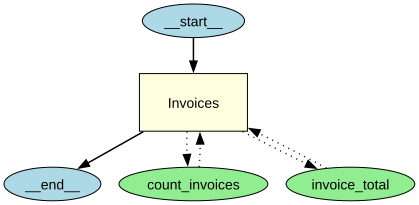

In [5]:
invoices_agent = Agent(
    name="Invoices",
    instructions="You answer invoice questions. Use your tools. Do not invent numbers.",
    model=model,
    tools=[count_invoices, invoice_total],
)

people_agent = Agent(
    name="People",
    instructions="You answer who-is-who questions. Use support_rep. Do not invent names.",
    model=model,
    tools=[support_rep],
)

show_graph(invoices_agent)


People is smaller: one tool. Then we stop drawing specialists and start drawing **how they connect**.


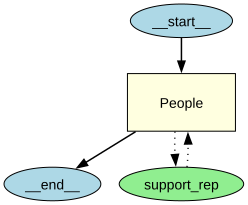

In [6]:
show_graph(people_agent)


### Part 1 — Code orchestrates

You are the desk. Two `Runner.run` tickets, `gather` (module 07). No third `Agent`. There is nothing for `draw_graph` to show as a manager — the graph is your cell.

You decided the order (together) and that both must run. Each specialist only sees its own prompt. People never hears about invoices. You combine the two `final_output`s. The model did not write the joined sentence unless you ask it to afterwards.


In [7]:
QUESTION = (
    "How many invoices does Helena Holý have, what is her total spend, "
    "and who is her support representative?"
)

trace_id = gen_trace_id()
print("Trace:", "https://platform.openai.com/traces/trace?trace_id=" + trace_id)

with trace("08 code orchestrates Helena", trace_id=trace_id):
    inv, ppl = await asyncio.gather(
        Runner.run(invoices_agent, "Helena Holý: how many invoices, and total spend?"),
        Runner.run(people_agent, "Who is the support rep for Helena Holý?"),
    )

print("Invoices:", inv.final_output)
print("People:  ", ppl.final_output)


Trace: https://platform.openai.com/traces/trace?trace_id=trace_977378d78a1d457ba27bca54d231c866


Invoices: Helena Holý has **7 invoices** and total spend of **$49.62**.
People:   Helena Holý’s support rep is **Steve Johnson**.


### Now look at the trace

Open the printed URL (or [platform.openai.com/traces](https://platform.openai.com/traces)). Two agent runs, sibling spans. You were the parent. That is orchestration by code.

### Part 2 — Agents as tools

The desk is now an `Agent`. Each specialist becomes a tool: `invoices_agent.as_tool(...)`. Control goes out and **comes back**. The desk writes the one sentence.

`as_tool` is not a handoff. The docstring of `as_tool` says so: the specialist gets a generated input, not the whole history, and the original agent continues. `draw_graph` should show Desk in yellow, `ask_invoices` and `ask_people` in green, **dotted arrows both ways**. The same `QUESTION`. One `Runner.run`.


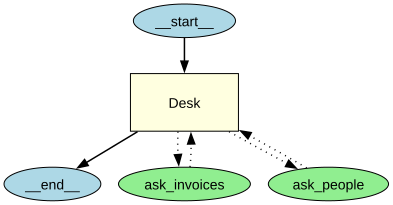

In [8]:
desk_tools = Agent(
    name="Desk",
    instructions=(
        "You are the shop desk. Use ask_invoices for counts and spend. "
        "Use ask_people for the support representative. "
        "Call both tools when the question needs both. Then answer in a few sentences."
    ),
    model=model,
    tools=[
        invoices_agent.as_tool(
            tool_name="ask_invoices",
            tool_description="Invoice count and total spend for a customer.",
        ),
        people_agent.as_tool(
            tool_name="ask_people",
            tool_description="Who the customer's support representative is.",
        ),
    ],
)

show_graph(desk_tools)


Dotted both ways: Desk → tool → Desk. That is the picture of control coming back. Now run it.


In [9]:
trace_id = gen_trace_id()
print("Trace:", "https://platform.openai.com/traces/trace?trace_id=" + trace_id)

with trace("08 agents as tools Helena", trace_id=trace_id):
    as_tools_out = await Runner.run(desk_tools, QUESTION)
print(as_tools_out.final_output)


Trace: https://platform.openai.com/traces/trace?trace_id=trace_12b0edf0df614750b6c55d6fa6ddae81


Helena Holý has **no invoices** and therefore **$0 total spend**. Her support representative is **Steve Johnson**.


### Now look at the trace

The desk span should contain two tool spans (`ask_invoices`, `ask_people`), and each of those contains the specialist's own tool calls (`count_invoices`, `invoice_total`, `support_rep`). Nested loops. You did not write a `for`.

If nano skips a tool, rerun this cell on `model_strong`. Do not add `tool_choice` to the desk — a miss is itself a lesson.

### Part 3 — Handoffs

`handoffs=[invoices_agent, people_agent]`. Control **passes across**. The specialist finishes the conversation. The desk does not get a turn after.

Solid arrows on the graph, one way, Desk → Invoices → end. No dotted return. Same `QUESTION` needs both specialists. A handoff can only live in one of them. Expect an incomplete sentence (invoices without the rep, or the reverse). That is not a bug in our wiring. It is what handoff *means*. Module 13 is when you decide whether you still want this. A question that only needs People will work. We run that second.


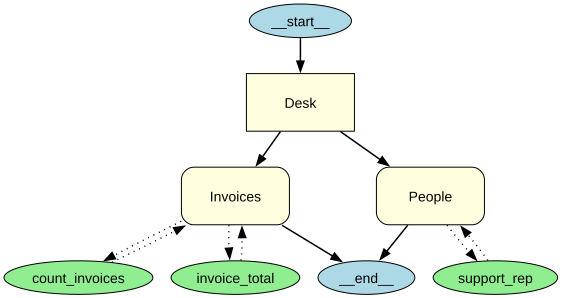

In [10]:
desk_handoff = Agent(
    name="Desk",
    instructions=(
        "You route. Do not answer from memory. "
        "Handoff to Invoices for counts and spend. "
        "Handoff to People for the support representative."
    ),
    model=model,
    handoffs=[invoices_agent, people_agent],
)

show_graph(desk_handoff)


Solid one-way arrows. Invoices and People are rounded yellow boxes (agents), not green ellipses. Each still has its own green tools. Start goes to Desk; end comes from a specialist, not from Desk.


In [11]:
trace_id = gen_trace_id()
print("Trace:", "https://platform.openai.com/traces/trace?trace_id=" + trace_id)

with trace("08 handoff Helena both", trace_id=trace_id):
    handoff_both = await Runner.run(desk_handoff, QUESTION)
print(handoff_both.final_output)
print("last agent:", handoff_both.last_agent.name)


Trace: https://platform.openai.com/traces/trace?trace_id=trace_59b19d8e8b4141128bafccc9a4d9ef7c


- **Invoices:** Helena Holý has **7** invoices.  
- **Total spend:** **$49.62**  
- **Support representative:** I don’t have access to that info with the available tools—please share the customer/account ID or tell me where that data is stored.
last agent: Invoices


Read `last_agent`. It should be Invoices **or** People, not Desk. The other specialist never ran. Compare that sentence to Part 2.

Now a question that only needs People. Handoffs are for this shape.


In [12]:
trace_id = gen_trace_id()
print("Trace:", "https://platform.openai.com/traces/trace?trace_id=" + trace_id)

with trace("08 handoff Helena people only", trace_id=trace_id):
    handoff_one = await Runner.run(
        desk_handoff,
        "Who is the support representative for Helena Holý?",
    )
print(handoff_one.final_output)
print("last agent:", handoff_one.last_agent.name)


Trace: https://platform.openai.com/traces/trace?trace_id=trace_d12737a55a5445babd0726554e0a4dd4


Helena Holý’s support representative is **Steve Johnson**.
last agent: People


## 3. Observe

Three pictures, one shop.

| Wiring | Who decides both specialists run? | Graph | Good when |
|---|---|---|---|
| Code | You | No manager box | The steps are known. Compliance likes this. |
| Agents as tools | The desk model | Dotted, both ways | One question, several specialists, you still want a single sentence. |
| Handoff | The desk model, once | Solid, one way | One destination. A transfer, not a meeting. |

Write down, from your runs:

- Did Part 2 name **7**, **49.62**, and **Steve Johnson**?
- What was `last_agent` on the two-part handoff? Which fact was missing?
- What was `last_agent` on the people-only handoff?

The traces tab is the same three stories as a timeline. Module 15 will grade traces. Today just match arrows to spans.

Keep this sentence for 09 and 13: **the framework did not choose the wiring. You did.** LangGraph will make the arrows state. CrewAI will call them a crew. The three options do not go away.


## 4. Challenge

Puja Srivastava is another Chinook customer.

Using **agents as tools** (Part 2 — a desk that can call both specialists), ask the same three things about Puja: how many invoices, total spend, support rep.

Bind `final_text` to the desk's `final_output`. The check looks for the three facts in that string. Do not type the numbers in. Let the tools run.


In [ ]:
# final_text = ...


In [ ]:
import re

assert final_text, "final_text should be the desk sentence"
low = final_text.lower()
assert re.search(r"\b6\b", final_text), "Puja's invoice count (6) should appear as its own number"
assert "36.64" in final_text.replace(",", ""), "Puja's spend should appear"
assert "jane" in low or "peacock" in low, "Puja's support rep should appear"
print("final_text:", final_text)
